In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# Display plots inside notebook
%matplotlib inline

In [2]:
df = pd.read_csv("agriculture_yield_dataset.csv")

df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [3]:
# Q1: Dataset Overview

# Number of rows and columns
print("Shape of dataset:", df.shape)

# Names of all columns
print("\nColumn Names:")
print(df.columns.tolist())

# Display first 10 records
print("\nFirst 10 Records:")
df.head(10)

Shape of dataset: (1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


1. The dataset contains 1500 rows and 8 columns.
2. It includes both numerical and categorical features.
3. The target variable appears to be 'yield_ton_per_hectare', which represents agricultural yield.

In [4]:
# Q2: Data Types and Missing Values

# Check data types
print("Data Types:\n")
print(df.dtypes)

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

Data Types:

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object

Missing Values:

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


## Q2 Observations

- The dataset contains both numerical and categorical features.
- Numerical columns are stored as float64 data type.
- The categorical columns are `crop_type` and `soil_type`.
- No missing values are present in the dataset.

In [5]:
# Q3: Descriptive Statistics

summary_stats = df.describe()

print(summary_stats)

# Feature with highest mean
highest_mean = summary_stats.loc['mean'].idxmax()
print("\nFeature with highest mean:", highest_mean)

# Feature with highest standard deviation
highest_std = summary_stats.loc['std'].idxmax()
print("Feature with highest standard deviation:", highest_std)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

## Q3 Observations

- `rainfall_mm` has the highest mean value among all numerical features.
- `rainfall_mm` also shows the highest standard deviation, indicating greater variability in rainfall values.
- The dataset contains a wide range of values across different agricultural factors.

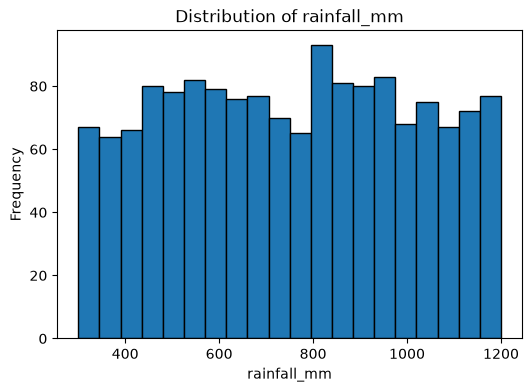

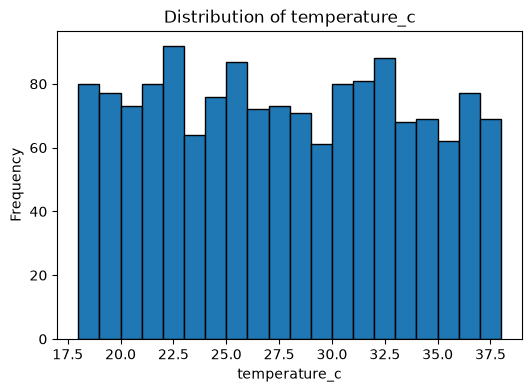

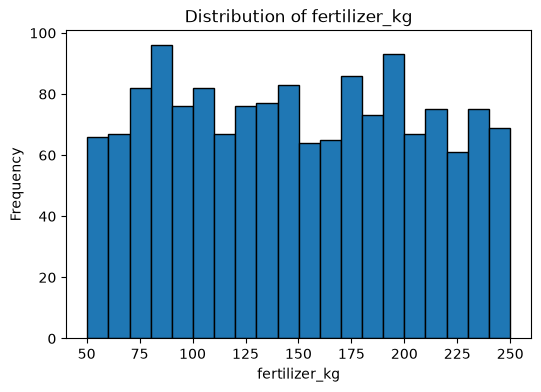

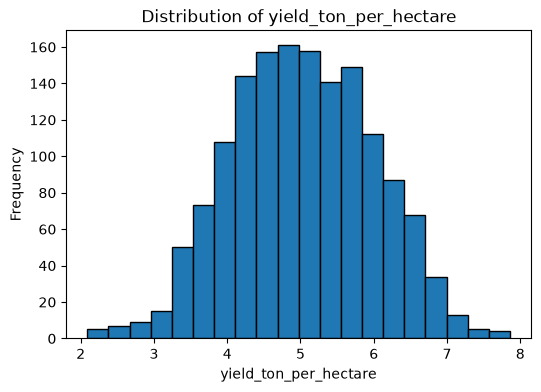

In [6]:
# Q4: Histograms

features = ['rainfall_mm', 'temperature_c',
            'fertilizer_kg', 'yield_ton_per_hectare']

for feature in features:
    plt.figure(figsize=(6,4))
    plt.hist(df[feature], bins=20, edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

## Q4 Observations

### Rainfall (rainfall_mm)
- The rainfall values are distributed fairly uniformly across the range.
- No significant skewness is observed.
- Extreme outliers are not clearly visible.

### Temperature (temperature_c)
- The temperature values are spread across a moderate range.
- The distribution appears approximately symmetric.
- Most observations are concentrated around the middle values.

### Fertilizer Usage (fertilizer_kg)
- Fertilizer usage is fairly evenly distributed.
- No strong skewness is present.
- The dataset does not show major outliers.

### Crop Yield (yield_ton_per_hectare)
- Crop yield values are concentrated around the central region.
- The distribution appears close to normal.
- Very few extreme values are observed.

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


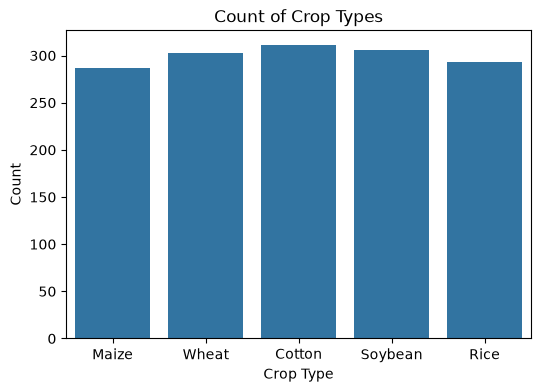

In [7]:
# Q5: Crop Type Analysis

crop_counts = df['crop_type'].value_counts()

print(crop_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='crop_type', data=df)
plt.title('Count of Crop Types')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.show()

## Q5 Observations

- The dataset contains five different crop types.
- Cotton is the most frequently occurring crop in the dataset.
- The distribution of crop records is fairly balanced across all crop categories.

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


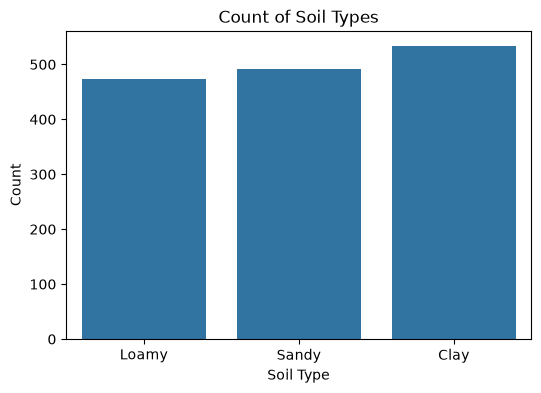

In [8]:
# Q6: Soil Type Analysis

soil_counts = df['soil_type'].value_counts()

print(soil_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='soil_type', data=df)
plt.title('Count of Soil Types')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.show()

## Q6 Observations

- The dataset contains three soil types: Clay, Sandy, and Loamy.
- Clay soil is the most frequently occurring soil type.
- The distribution among soil types is relatively balanced.

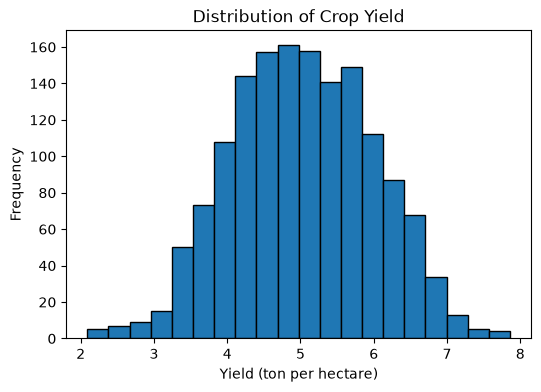

In [9]:
# Q7: Yield Distribution

plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'],
         bins=20,
         edgecolor='black')

plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (ton per hectare)')
plt.ylabel('Frequency')
plt.show()

## Q7 Observations

- The yield distribution appears approximately normal.
- Most yield values are concentrated around the central region.
- No major outliers are visible in the histogram.

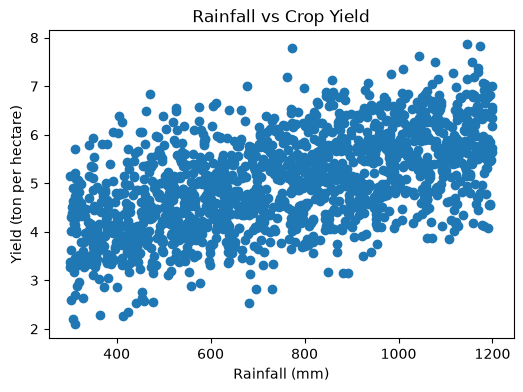

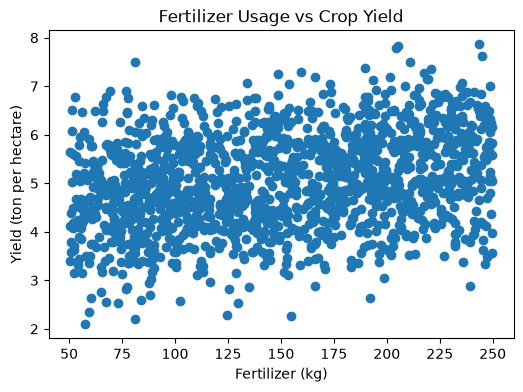

In [10]:
# Rainfall vs Yield

plt.figure(figsize=(6,4))
plt.scatter(df['rainfall_mm'],
            df['yield_ton_per_hectare'])

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (ton per hectare)')
plt.show()


# Fertilizer vs Yield

plt.figure(figsize=(6,4))
plt.scatter(df['fertilizer_kg'],
            df['yield_ton_per_hectare'])

plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield (ton per hectare)')
plt.show()

## Q8 Observations

- Crop yield generally increases with increasing rainfall.
- Fertilizer usage also affects yield, but the relationship is weaker.
- Rainfall shows a stronger positive relationship with crop yield.

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

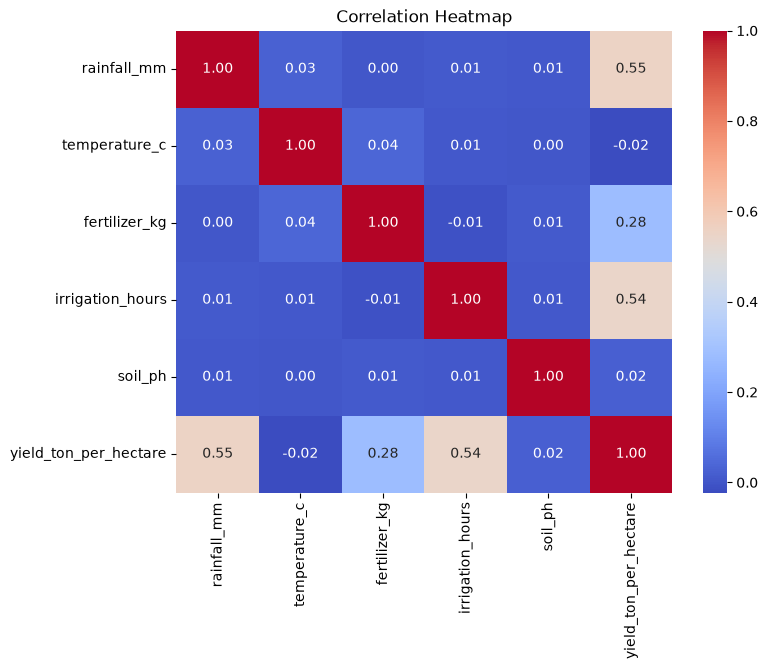

In [11]:
# Q9: Correlation Matrix

corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

## Q9 Observations

- Rainfall has the strongest positive correlation with crop yield.
- Irrigation hours also show a strong positive relationship with yield.
- Fertilizer usage moderately influences crop yield.

In [12]:
# Average yield by crop type

crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print("Average Yield by Crop Type:\n")
print(crop_yield)


# Average yield by soil type

soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print("\nAverage Yield by Soil Type:\n")
print(soil_yield)

Average Yield by Crop Type:

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


## Q10 Observations

- Rice has the highest average crop yield among all crop types.
- Loamy soil provides the highest average yield.
- Sandy soil has the lowest average yield in the dataset.

In [13]:
# Q11: Identify categorical columns

categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='str')


/var/folders/58/9j8jcp5d793_118hr_10_ln80000gn/T/ipykernel_28387/4090507558.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


## Q11 Observations

- The categorical columns in the dataset are `crop_type` and `soil_type`.
- One-Hot Encoding was applied to convert categorical variables into numerical form.
- The transformed dataset can now be used for machine learning models.

In [16]:
# Q12: Separate features and target

X = df_encoded.drop('yield_ton_per_hectare', axis=1)

y = df_encoded['yield_ton_per_hectare']

print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

Input Features (X):
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Maize  crop_type_Rice  crop_type_Soybean  crop_type_Wheat  \
0             True           False              False            False   
1             True           False              False            False   
2            False           False              False             True   
3             True           False              False            False   
4            False           False              False            False   

   soil_type_Loamy  soil_type_Sandy  
0             True            False  
1       

In [15]:
# Apply One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


## Q12 Observations

- The input features are stored in `X`.
- The target variable is `yield_ton_per_hectare`.
- The target variable represents agricultural yield and will be predicted using machine learning.

In [17]:
# Q13: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 11)
X_test shape: (300, 11)
y_train shape: (1200,)
y_test shape: (300,)


## Q13 Observations

- The dataset was split into 80% training data and 20% testing data.
- The training set is used to train the model, while the testing set is used to evaluate its performance.
- Random state 42 was used to ensure reproducibility.

In [18]:
# Q14: Train Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

# Display intercept
print("Intercept:")
print(model.intercept_)

# Display coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nCoefficients:")
print(coefficients)

# Feature with highest positive coefficient
highest_feature = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print("\nFeature with Highest Positive Coefficient:")
print(highest_feature)

Intercept:
1.5871320277361227

Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object


## Q14 Observations

- A Linear Regression model was trained using the training dataset.
- The model learned coefficients for each input feature.
- The feature with the highest positive coefficient has the strongest positive influence on crop yield according to the model.